In [1]:
import kagglehub

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(path)

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 612M/612M [00:15<00:00, 41.3MB/s] 

Extracting files...


C:\Users\USER\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from PIL import Image
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D,Dense,Flatten,MaxPool2D,Dropout
from keras.models import Sequential
import os


In [5]:
train_data_path=path+"\\Train"
data=[]
labels=[]
classes=43
for i in range(classes):
    image_path=train_data_path+"\\"+str(i)
    for img_name in os.listdir(image_path):
        img=Image.open(image_path+"\\"+img_name)
        img=img.resize((30,30))
        img=np.array(img)
        data.append(img)
        labels.append(i)

data=np.array(data)
labels=np.array(labels)



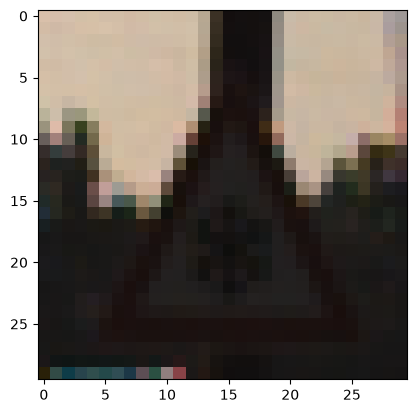

In [6]:
sample_path=r"C:\Users\USER\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1\Train\30\00030_00000_00015.png"
sample=Image.open(sample_path)
sample=sample.resize((30,30))
sample=np.array(sample)
plt.imshow(sample)
plt.show()


In [11]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(data,labels,test_size=0.2,random_state=42)
print(Xtrain.shape)
print(Xtest.shape)

(31367, 30, 30, 3)
(7842, 30, 30, 3)


In [12]:
ytrain=to_categorical(ytrain,classes)
ytest=to_categorical(ytest,classes)
Xtrain=Xtrain/255
Xtest=Xtest/255


In [ ]:
model=Sequential()
model.add(Conv2D(filters=32,kernel_size=(5,5),activation="relu",input_shape=Xtrain.shape[1:]))
